### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

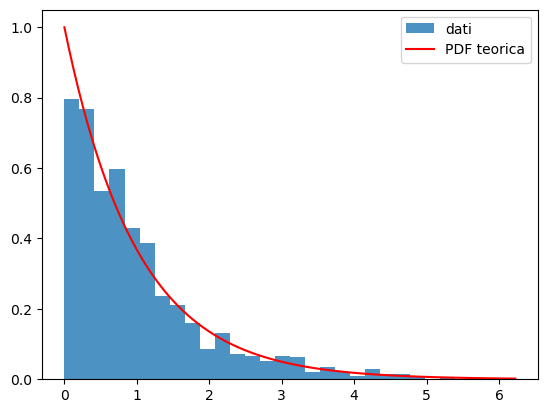

In [3]:
# 1.
k = 1
dist = sp.stats.gamma(k)
data = dist.rvs(size=1000) # 1000 valori

# 2.
plt.hist(data, bins=30, density=True, alpha=0.8, label="dati")
x = np.linspace(min(data), max(data), 100)
plt.plot(x, dist.pdf(x), "r-", label="PDF teorica") # PDF sovrapposta

plt.legend()
plt.show()

In [16]:
# 3.
params = sp.stats.gamma.fit(data)
print("parametro di forma stimato:",params[0])

parametro di forma stimato: 0.9784175029404906


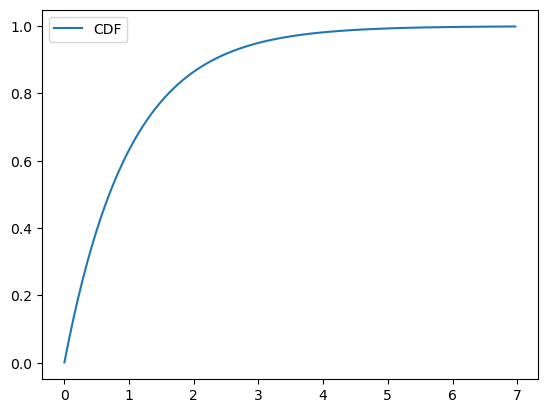

In [17]:
# 4.
plt.plot(x, dist.cdf(x), label="CDF")
plt.legend()
plt.show()    

In [20]:
# 5.
var_data = np.var(data)
print("varianza:",var_data)

varianza: 0.9041222570223356


### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

lineare -> MAE: 4.1224038134150485 RMSE: 4.844160908155007
quadratico -> MAE: 4.089393072079965 RMSE: 4.595961162666933


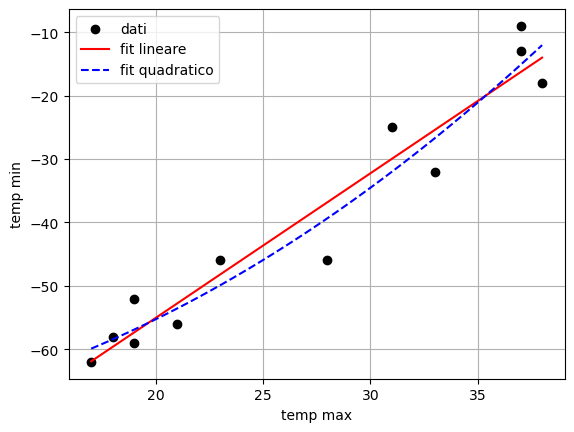

In [5]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt

x = temp_max
y = temp_min

# ax + b
coeff1 = np.polyfit(x, y, 1) 
y_pred1 = np.polyval(coeff1, x)

# ax^2 + bx + c
coeff2 = np.polyfit(x, y, 2)
y_pred2 = np.polyval(coeff2, x)

# lineare
mae1 = np.mean(np.abs(y - y_pred1))
rmse1 = np.sqrt(np.mean((y - y_pred1)**2))

# quadratico
mae2 = np.mean(np.abs(y - y_pred2))
rmse2 = np.sqrt(np.mean((y - y_pred2)**2))


print("lineare -> MAE:", mae1, "RMSE:", rmse1)
print("quadratico -> MAE:", mae2, "RMSE:", rmse2)

x_line = np.linspace(min(x), max(x), 100)

plt.scatter(x, y, color="black", label="dati")

plt.plot(x_line, np.polyval(coeff1, x_line), "r-", label="fit lineare")
plt.plot(x_line, np.polyval(coeff2, x_line), "b--", label="fit quadratico")

plt.xlabel("temp max")
plt.ylabel("temp min")
plt.grid(True)
plt.legend()
plt.show()

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [6]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


[-0.04121512 29.59985476]
MAE: 2.6054734857610677
RMSE: 3.1482072740002796


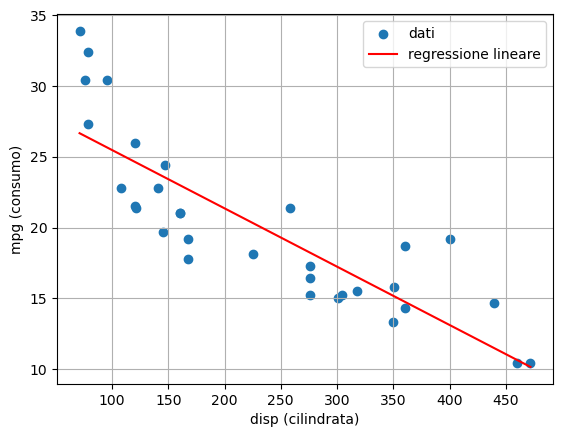

In [7]:
# metodo 1
x = df["disp"].values
y = df["mpg"].values

coeff = np.polyfit(x, y, 1)
print(coeff)

y_pred = np.polyval(coeff, x)

mae = np.mean(np.abs(y - y_pred))
rmse = np.sqrt(np.mean((y - y_pred)**2))

print("MAE:", mae)
print("RMSE:", rmse)

x_line = np.linspace(min(x), max(x), 100)

plt.scatter(x, y, label="dati")
plt.plot(x_line, np.polyval(coeff, x_line), "r-", label="regressione lineare")

plt.xlabel("disp (cilindrata)")
plt.ylabel("mpg (consumo)")
plt.grid(True)
plt.legend()
plt.show()

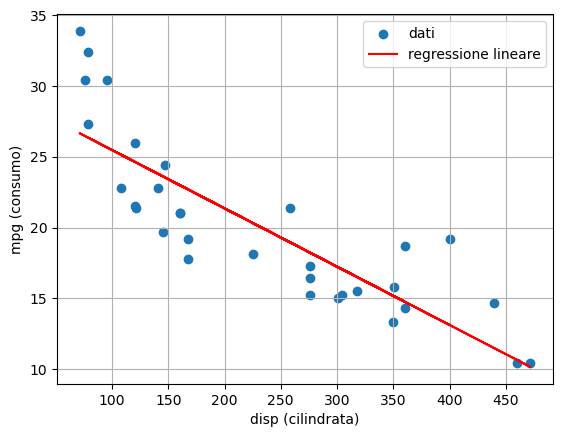

In [8]:
# metodo 2
x = df["disp"].values
y = df["mpg"].values

def lineare(x, a, b):
    return a * x + b

popt, _ = sp.optimize.curve_fit(lineare, x, y)
y_pred = lineare(x, *popt)

x_line = np.linspace(min(x), max(x), 100)

plt.scatter(x, y, label="dati")
plt.plot(x, y_pred, "r-", label="regressione lineare")

plt.xlabel("disp (cilindrata)")
plt.ylabel("mpg (consumo)")
plt.grid(True)
plt.legend()
plt.show()